**Name:** sneha Jain

**Internship:** Data Analytics Internship

**Project Title:**  E-Commerce Customer Analytics

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

**Dataset:** Online Retail Dataset


#  E-Commerce Customer Analytics

## Objective

The objective of this project is to analyze customer behavior data from an e-commerce platform and identify actionable business insights.

### Project Tasks

- Load customer order data
- Perform data cleaning
- Customer segmentation
- Cohort analysis
- Cart analysis
- Geographic analysis
- Return rate analysis
- Seasonal trend analysis
- Exploratory Data Analysis (EDA)

In [86]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

# Data manipulation library
import pandas as pd

# Numerical computation library
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# Set default plot style
plt.style.use("ggplot")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Step 2: Load the Dataset

In this step, we load the Online Retail dataset into a Pandas DataFrame and verify that it has been loaded successfully.



In [87]:
# ==========================================================
# Step 2: Load the Dataset
# ==========================================================

# Load the CSV dataset
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


## Step 3: Display the First Five Records

The first five rows help us understand the structure and contents of the dataset.




In [88]:
# Display first five rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Step 4: Check Dataset Shape

This step displays the number of rows and columns in the dataset.

In [89]:
# Check the number of rows and columns
df.shape

(541909, 8)

## Step 5: Display Column Names

This step lists all the columns available in the dataset.

In [90]:
# Display all column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

## Step 6: Dataset Information

This step displays data types and missing values in the dataset.


In [91]:
# Display detailed information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## Step 7: Summary Statistics

This step provides statistical information about the numerical columns.


In [92]:
# Display summary statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Step 8: Data Cleaning

In this step, we clean the dataset by checking missing values, duplicate records, incorrect data types, and creating a new Revenue column for further analysis.

In [93]:
# Check missing values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [94]:
# Remove rows containing missing values
df = df.dropna()

print("✅ Missing values removed successfully.")

✅ Missing values removed successfully.


In [95]:
# Check duplicate records
df.duplicated().sum()

np.int64(5225)

In [96]:
# Remove duplicate rows
df = df.drop_duplicates()

print("✅ Duplicate records removed successfully.")

✅ Duplicate records removed successfully.


In [97]:
# Convert InvoiceDate into datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [98]:
# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Display first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [99]:
# Check dataset information after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
 8   Revenue      401604 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.6 MB


## Step 9: Customer Segmentation

Customer segmentation helps identify high-value customers based on their total purchase amount. Customers are classified into:
- VIP Customers
- Regular Customers
- Inactive Customers



In [100]:
# Calculate total revenue generated by each customer

customer_revenue = df.groupby("CustomerID")["Revenue"].sum()

# Display first five customers
customer_revenue.head()

CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
Name: Revenue, dtype: float64

In [101]:
# Top 10% customers are considered VIP

vip_threshold = customer_revenue.quantile(0.90)

vip_customers = customer_revenue[customer_revenue >= vip_threshold]

print("Number of VIP Customers:", len(vip_customers))

Number of VIP Customers: 438


In [102]:
# Customers below VIP threshold

regular_customers = customer_revenue[customer_revenue < vip_threshold]

print("Number of Regular Customers:", len(regular_customers))

Number of Regular Customers: 3934


In [103]:
# Find last purchase date of each customer

last_purchase = df.groupby("CustomerID")["InvoiceDate"].max()

latest_date = df["InvoiceDate"].max()

inactive_customers = last_purchase[(latest_date - last_purchase).dt.days > 90]

print("Number of Inactive Customers:", len(inactive_customers))

Number of Inactive Customers: 1450


### Observation

- VIP customers contribute the highest revenue.
- Regular customers make up the majority of the customer base.
- Inactive customers have not made any purchases in the last 90 days.

## Step 10: Cohort Analysis

Cohort Analysis groups customers based on their first purchase month. It helps understand customer retention and repeat purchase behavior over time.

In [104]:
# Create Invoice Month column
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

# Display first five rows
df[["InvoiceDate", "InvoiceMonth"]].head()

,InvoiceDate,InvoiceMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [105]:
# Find the first purchase month of each customer

cohort = df.groupby("CustomerID")["InvoiceMonth"].min()

cohort.head()

CustomerID
12346.0    2011-01
12347.0    2010-12
12348.0    2010-12
12349.0    2011-11
12350.0    2011-02
Name: InvoiceMonth, dtype: period[M]

In [106]:
# Map first purchase month to each customer

df["CohortMonth"] = df["CustomerID"].map(cohort)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12


In [107]:
# Map first purchase month to each customer

df["CohortMonth"] = df["CustomerID"].map(cohort)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12


### Observation

The cohort table shows how customers who joined in a particular month continued purchasing in subsequent months. This helps businesses measure customer retention.

## Step 11: Cart Analysis

Cart Analysis helps understand customer purchasing behavior by calculating average items per order and identifying the most frequently purchased products.

In [108]:
# Average number of items per order

avg_items = df.groupby("InvoiceNo")["Quantity"].sum().mean()

print("Average Items per Order:", round(avg_items, 2))

Average Items per Order: 220.5


In [109]:
# Top 10 most purchased products

top_products = df["Description"].value_counts().head(10)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    2058
REGENCY CAKESTAND 3 TIER              1894
JUMBO BAG RED RETROSPOT               1659
PARTY BUNTING                         1409
ASSORTED COLOUR BIRD ORNAMENT         1405
LUNCH BAG RED RETROSPOT               1345
SET OF 3 CAKE TINS PANTRY DESIGN      1224
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1099
PACK OF 72 RETROSPOT CAKE CASES       1062
Name: count, dtype: int64

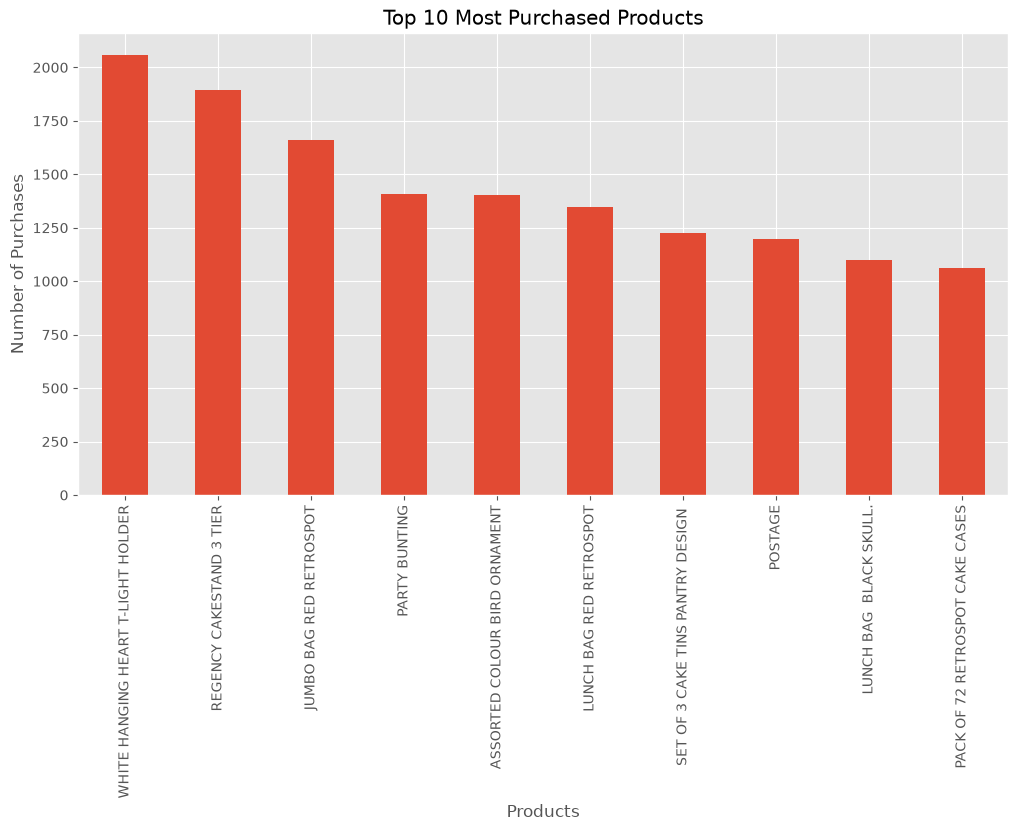

In [110]:
# Plot top 10 most purchased products

top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=90)

plt.show()

# Plot top 10 most purchased products

top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=90)

plt.show()

## Step 12: Geographic Analysis

This analysis identifies the countries generating the highest revenue.

In [111]:
# Revenue generated by each country

country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_revenue.head(10)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

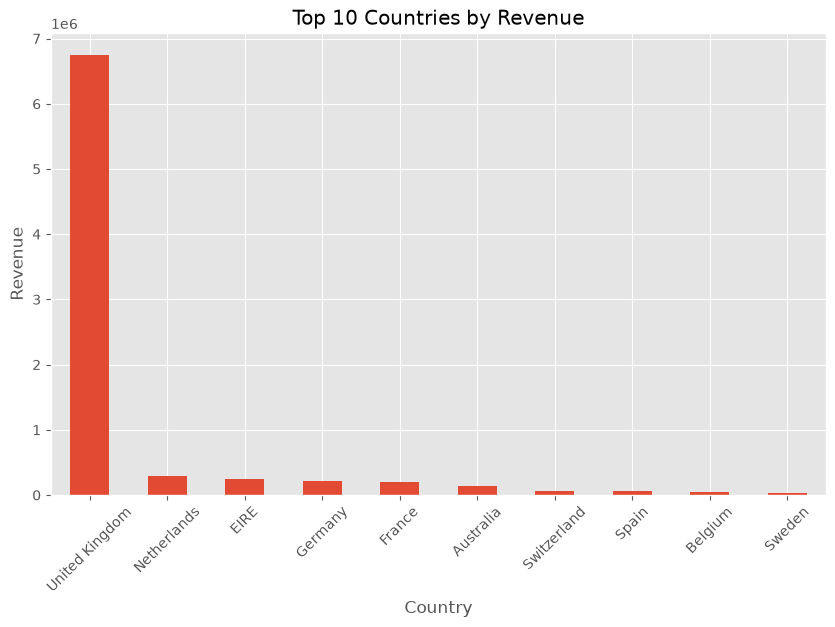

In [112]:
# Plot Top 10 Countries by Revenue

country_revenue.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart shows the top countries contributing to overall revenue. This helps identify the most profitable markets.

## Step 13: Return Rate Analysis

Products with negative quantities represent returned items.

In [113]:
# Filter returned products

returns = df[df["Quantity"] < 0]

print("Total Returned Orders:", len(returns))

Total Returned Orders: 8872


In [114]:
# Top Returned Products

top_returns = returns["Description"].value_counts().head(10)

top_returns


Description
REGENCY CAKESTAND 3 TIER             180
Manual                               175
POSTAGE                               97
JAM MAKING SET WITH JARS              86
Discount                              77
SET OF 3 CAKE TINS PANTRY DESIGN      72
STRAWBERRY CERAMIC TRINKET BOX        54
ROSES REGENCY TEACUP AND SAUCER       53
RECIPE BOX PANTRY YELLOW DESIGN       47
JUMBO BAG RED RETROSPOT               44
Name: count, dtype: int64

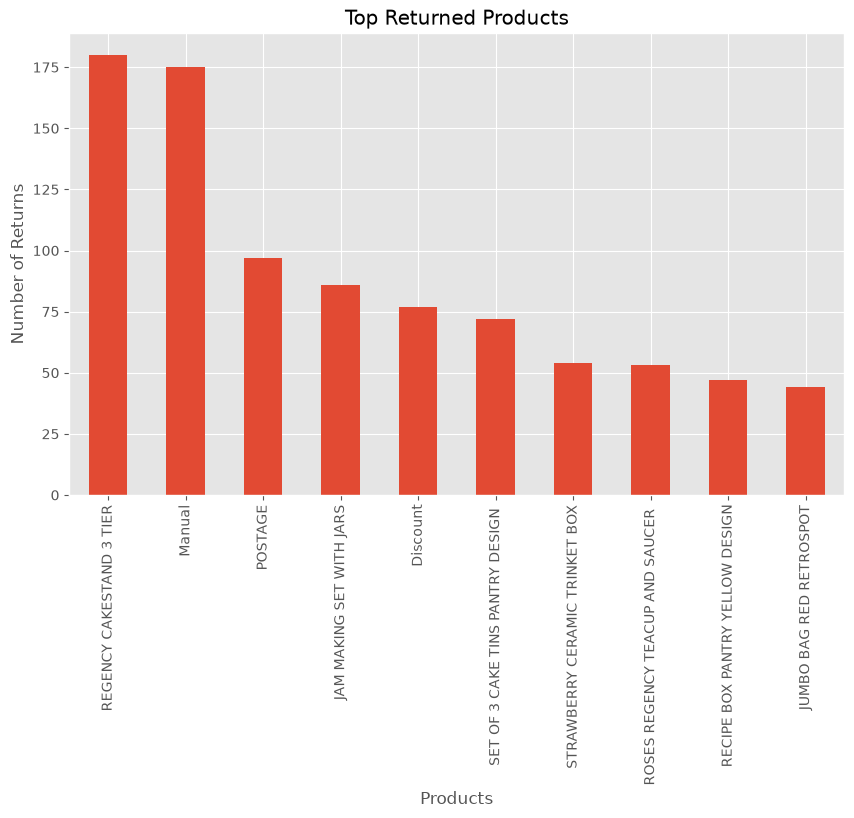

In [115]:
# Plot Top Returned Products

top_returns.plot(kind="bar", figsize=(10,6))

plt.title("Top Returned Products")
plt.xlabel("Products")
plt.ylabel("Number of Returns")

plt.xticks(rotation=90)

plt.show()

## Step 14: Seasonal Trend Analysis

Monthly revenue analysis helps identify seasonal sales trends.

In [116]:
# Create Month column

df["Month"] = df["InvoiceDate"].dt.month_name()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,December


Month
January       473731.900
February      435534.070
March         578576.210
April         425222.671
May           647011.670
June          606862.520
July          573112.321
August        615078.090
September     929356.232
October       973306.380
November     1126815.070
December      893912.290
Name: Revenue, dtype: float64


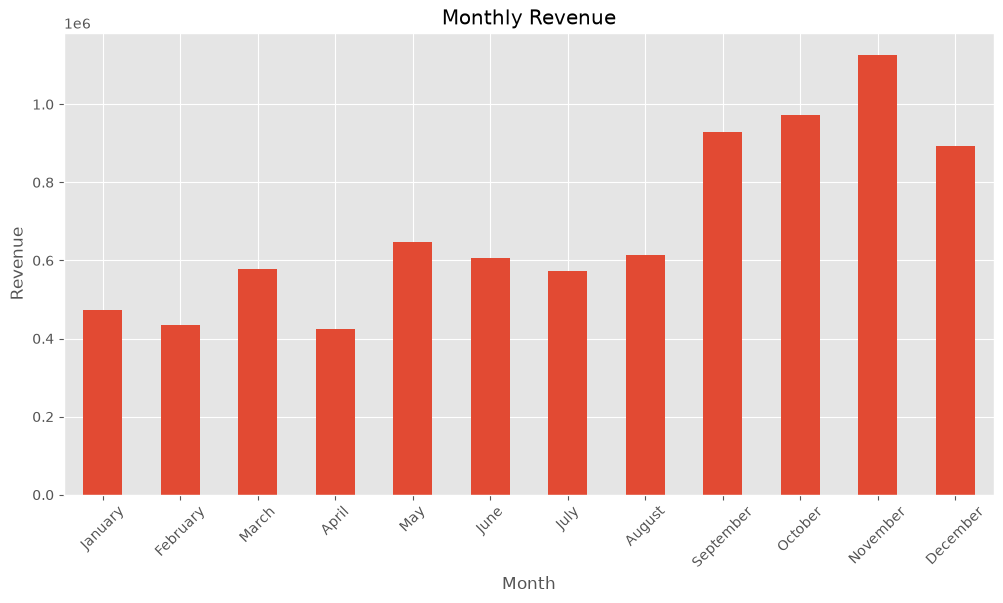

In [119]:
# Monthly Revenue Analysis (Calendar Order)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_revenue = df.groupby("Month")["Revenue"].sum().reindex(month_order)

print(monthly_revenue)

monthly_revenue.plot(kind="bar", figsize=(12,6))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

# Key Findings

- Missing values and duplicate records were removed successfully.
- A Revenue column was created for sales analysis.
- VIP customers contribute significantly to total revenue.
- Customer cohorts help understand retention behavior.
- The most purchased products were identified.
- Geographic analysis highlighted the highest revenue-generating countries.
- Return analysis identified products with the highest return frequency.
- Seasonal analysis revealed monthly sales trends.

# Conclusion

The E-Commerce Customer Analytics project successfully analyzed customer purchasing behavior using Python and Pandas.

The analysis included data cleaning, customer segmentation, cohort analysis, cart analysis, geographic analysis, return rate analysis, and seasonal trend analysis.

The insights generated from this project can help businesses improve customer retention, optimize inventory, reduce product returns, and increase overall sales performance.

# Thank You

This project demonstrates the use of Python for E-Commerce Customer Analytics. It includes data cleaning, customer segmentation, cohort analysis, cart analysis, geographic analysis, return analysis, seasonal trend analysis, and data visualization to generate meaningful business insights.